### Environment Setup and Pipeline Execution

In [ ]:
import sys
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Import data preparation module
sys.path.append('../src')
import data_prep

# Magic commands to automatically reload the module if you change the .py file
%load_ext autoreload
%autoreload 2

# Visual settings
plt.style.use('seaborn-v0_8-darkgrid')

# Project constants
RAW_PATH = "../data/raw"
SPLIT_DATE = '2016-04-24'

print("Starting the data preparation pipeline...")
# Running the robust pipeline for store CA_1 to iterate quickly
df, df_ground_truth = data_prep.build_pipeline(RAW_PATH, split_date=SPLIT_DATE, store_filter='CA_1')

print(f"\nPipeline finished. Main dataframe shape: {df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Starting the data preparation pipeline...
--- Starting Data Prep Pipeline ---
Loading raw files...
Melting sales data (Wide to Long)...
Merging with calendar and prices...


### Feature Selection and Temporal Split

In [2]:
print("Preparing features and splitting data...")

# Define the features the model will use to learn
# We strictly exclude identifiers, dates, and the target variable ('sales')
features = [
    'sell_price', 'day_of_month', 'day_of_week', 'week_of_year',
    'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2',
    'snap_CA', 'snap_TX', 'snap_WI',
    'sales_lag_7', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_28'
]

target = 'sales'

# Training Dataset (Data up to 2016-04-24)
# We drop rows with NaN in 'rolling_mean_28' because the model cannot learn from empty historical windows
train_mask = (df['date'] <= SPLIT_DATE) & (df['rolling_mean_28'].notnull())
X_train = df[train_mask][features]
y_train = df[train_mask][target]

# Testing Dataset (The blind 28-day window)
test_mask = (df['date'] > SPLIT_DATE)
X_test = df[test_mask][features]

# Keep 'id' and 'date' to merge the predictions back with the ground truth later
test_keys = df[test_mask][['id', 'date']]

print(f"Training shape: {X_train.shape}")
print(f"Testing shape (Blind Window): {X_test.shape}")

Preparing features and splitting data...
Training shape: (4535200, 15)
Testing shape (Blind Window): (85372, 15)


### LightGBM Configuration

In [3]:
print("Configuring LightGBM...")

# Explicitly defining categorical features before dataset creation
categorical_features = ['day_of_week', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']

# Pass the categorical features DIRECTLY into the Dataset constructor
train_data = lgb.Dataset(
    X_train, 
    label=y_train, 
    categorical_feature=categorical_features
)

# Baseline hyperparameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'verbose': -1,
    'random_state': 42
}

Configuring LightGBM...


### Model Training and Global Importance

Training the baseline LightGBM model...
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
Training completed successfully!


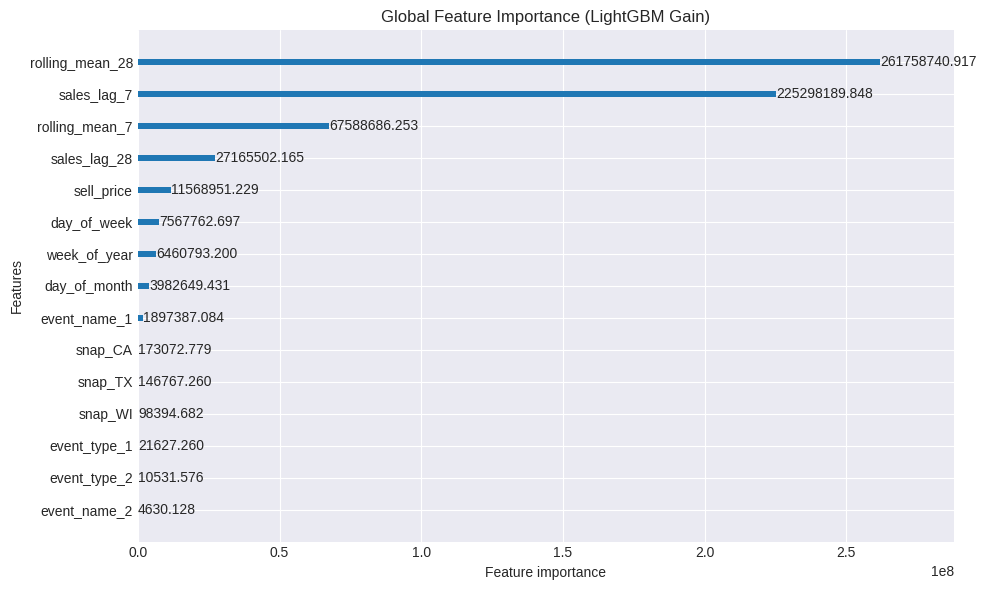

In [4]:
print("Training the baseline LightGBM model...")

# Train the model (removed categorical_feature from here)
num_round = 200
model = lgb.train(
    params, 
    train_data, 
    num_boost_round=num_round
)

print("Training completed successfully!")

# Plot Global Feature Importance
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=plt.gca())
plt.title('Global Feature Importance (LightGBM Gain)')
plt.tight_layout()
plt.show()

### Inference and Error Evaluation

In [5]:
print("Generating predictions for the blind 28-day window...")

# Generate predictions
predictions = model.predict(X_test)

# Attach predictions back to the identifiers
results = test_keys.copy()
results['predicted_sales'] = predictions

# Merge with the ground truth gabarito we isolated in the data prep phase
eval_df = pd.merge(results, df_ground_truth, on=['id', 'date'], how='inner')

# Calculate baseline metrics
# Note: While WRMSSE is the official M5 metric, RMSE and MAE are excellent 
# proxies for this single-store (CA_1) validation step.
rmse = np.sqrt(mean_squared_error(eval_df['actual_sales'], eval_df['predicted_sales']))
mae = mean_absolute_error(eval_df['actual_sales'], eval_df['predicted_sales'])

print(f"\n--- Baseline Validation Metrics (CA_1 Store) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

display(eval_df.head())

Generating predictions for the blind 28-day window...

--- Baseline Validation Metrics (CA_1 Store) ---
RMSE: 2.7179
MAE:  1.2207


,id,date,predicted_sales,actual_sales
0,FOODS_1_001_CA_1_evaluation,2016-04-25,1.187969,2
1,FOODS_1_001_CA_1_evaluation,2016-04-26,0.801584,0
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.790026,0
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.641526,0
4,FOODS_1_001_CA_1_evaluation,2016-04-29,1.095086,0


### Isolating Failures for XAI Analysis

In [6]:
# The methodology requires evaluating SHAP and LIME behavior where the algorithm fails.
# Let's calculate the absolute error per instance to find the worst predictions.
eval_df['absolute_error'] = np.abs(eval_df['actual_sales'] - eval_df['predicted_sales'])

# Sort to find the top failures
worst_predictions = eval_df.sort_values(by='absolute_error', ascending=False)

print("Top 5 worst predictions (Prime candidates for XAI evaluation):")
display(worst_predictions.head())

# Save this evaluation dataframe to use in the upcoming XAI notebook
eval_df.to_parquet('../data/processed/ca1_evaluation_results.parquet', index=False)
print("\nEvaluation results saved successfully.")

Top 5 worst predictions (Prime candidates for XAI evaluation):


,id,date,predicted_sales,actual_sales,absolute_error
20523,FOODS_3_120_CA_1_evaluation,2016-05-22,17.319776,114,96.680224
19668,FOODS_3_090_CA_1_evaluation,2016-05-07,19.467096,104,84.532904
2431,FOODS_1_088_CA_1_evaluation,2016-05-18,1.013381,77,75.986619
19667,FOODS_3_090_CA_1_evaluation,2016-05-06,17.879252,89,71.120748
33003,FOODS_3_566_CA_1_evaluation,2016-05-14,4.813652,66,61.186348



Evaluation results saved successfully.
